In [1]:
import pandas as pd
import glob
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
UNCONSTRAINING_MODELS = ['Naive_Est', 'EM_Est', 'MARSS_Est', 'EMXPrice_Est', 'MARSSXPrice_Est']

In [3]:
files = glob.glob("../Unconstraining/unconstrained_results/*.parquet")

df_all = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)
# drop nans in estimation columns since they are the initial burn-in period where estimation is not possible
df_all = df_all.dropna(subset=['Naive_Est', 'EM_Est', 'MARSS_Est', 'EMXPrice_Est', 'MARSSXPrice_Est'], how='all')
df_all = df_all.reset_index(drop=True)
print(df_all.shape)

od_pairs = list(df_all[['Origin', 'Destination']].drop_duplicates().itertuples(index=False, name=None))
# let's keep results in dictionaries with schema [(origin, destination)][unconstrainer_name or oracle]:
unconstraining_results = {}
for origin, destination in tqdm(od_pairs):
    unconstraining_results[(origin, destination)] = {}
    for model_name in UNCONSTRAINING_MODELS:
        # save the df with Date and Demand
        unconstraining_results[(origin, destination)][model_name] = df_all[
            (df_all['Origin'] == origin) &
            (df_all['Destination'] == destination)
        ][['Date', model_name]].rename(columns={model_name: 'Demand'}).reset_index(drop=True)
    # also save the oracle (final true demand)
    unconstraining_results[(origin, destination)]['Oracle'] = df_all[
        (df_all['Origin'] == origin) &
        (df_all['Destination'] == destination)
    ][['Date', 'Final_True_Demand']].rename(columns={'Final_True_Demand': 'Demand'}).reset_index(drop=True)

# print sample
print("Sample of unconstraining results:")
for (origin, destination), models in list(unconstraining_results.items())[:3]:  # Print first 3 OD pairs
    print(f"\nOD Pair: {origin} -> {destination}")
    for model_name, df in models.items():
        print(f"  {model_name}:")
        print(df.head())
        print(df.shape)

(295920, 30)


100%|██████████| 90/90 [00:16<00:00,  5.61it/s]

Sample of unconstraining results:

OD Pair: CAN -> CGO
  Naive_Est:
        Date   Demand
0 2016-12-31  12254.0
1 2017-01-01  10090.0
2 2017-01-02  15560.0
3 2017-01-03  18613.0
4 2017-01-04  15296.0
(3288, 2)
  EM_Est:
        Date   Demand
0 2016-12-31  12254.0
1 2017-01-01  10090.0
2 2017-01-02  15560.0
3 2017-01-03  18613.0
4 2017-01-04  15296.0
(3288, 2)
  MARSS_Est:
        Date   Demand
0 2016-12-31  12254.0
1 2017-01-01  10090.0
2 2017-01-02  15560.0
3 2017-01-03  18613.0
4 2017-01-04  15296.0
(3288, 2)
  EMXPrice_Est:
        Date   Demand
0 2016-12-31  12254.0
1 2017-01-01  10090.0
2 2017-01-02  15560.0
3 2017-01-03  18613.0
4 2017-01-04  15296.0
(3288, 2)
  MARSSXPrice_Est:
        Date   Demand
0 2016-12-31  12254.0
1 2017-01-01  10090.0
2 2017-01-02  15560.0
3 2017-01-03  18613.0
4 2017-01-04  15296.0
(3288, 2)
  Oracle:
        Date   Demand
0 2016-12-31  12254.0
1 2017-01-01  10090.0
2 2017-01-02  15560.0
3 2017-01-03  18613.0
4 2017-01-04  15296.0
(3288, 2)

OD Pair: CA

In [4]:
df = unconstraining_results[('PVG', 'JFK')]['MARSSXPrice_Est']
df

,Date,Demand
0,2016-12-31,39500.000000
1,2017-01-01,22775.000000
2,2017-01-02,57003.000000
3,2017-01-03,56349.000000
4,2017-01-04,47020.000000
...,...,...
3283,2025-12-27,62957.000000
3284,2025-12-28,47480.000000
3285,2025-12-29,110832.658146
3286,2025-12-30,80087.000000


In [5]:
df.describe()

,Date,Demand
count,3288,3288.000000
mean,2021-07-01 12:00:00,57968.559303
min,2016-12-31 00:00:00,14556.000000
25%,2019-04-01 18:00:00,42701.000000
50%,2021-07-01 12:00:00,56418.000000
75%,2023-10-01 06:00:00,70454.250000
max,2025-12-31 00:00:00,115079.382921
std,NaN,20367.360465


In [6]:
# # trim to only last 3 years for testing 
# # comment this cell out if you want to use the full 10 years of data
# df = df[df['Date'] >= '2023-01-01'].reset_index(drop=True)
# print(df.shape)

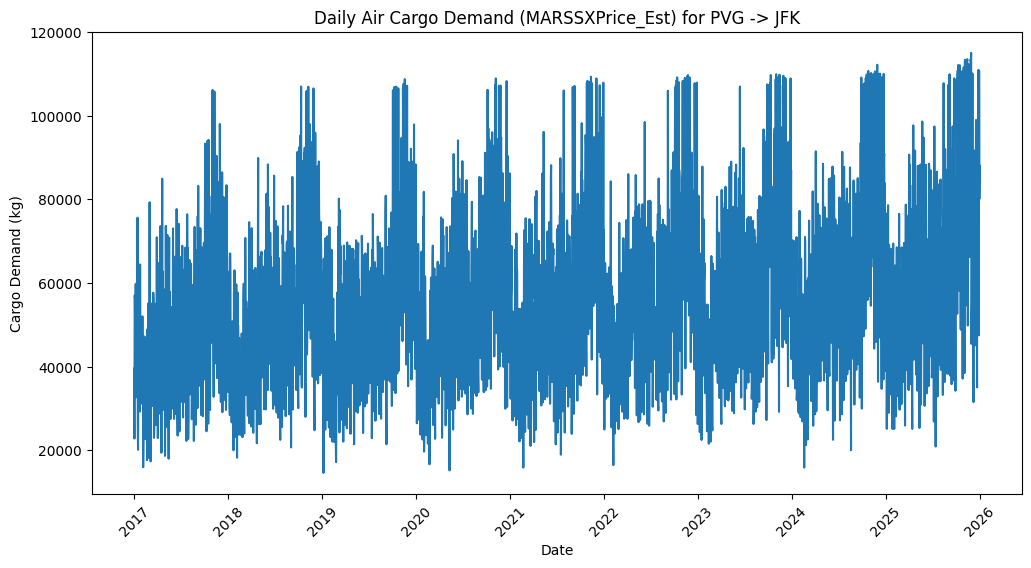

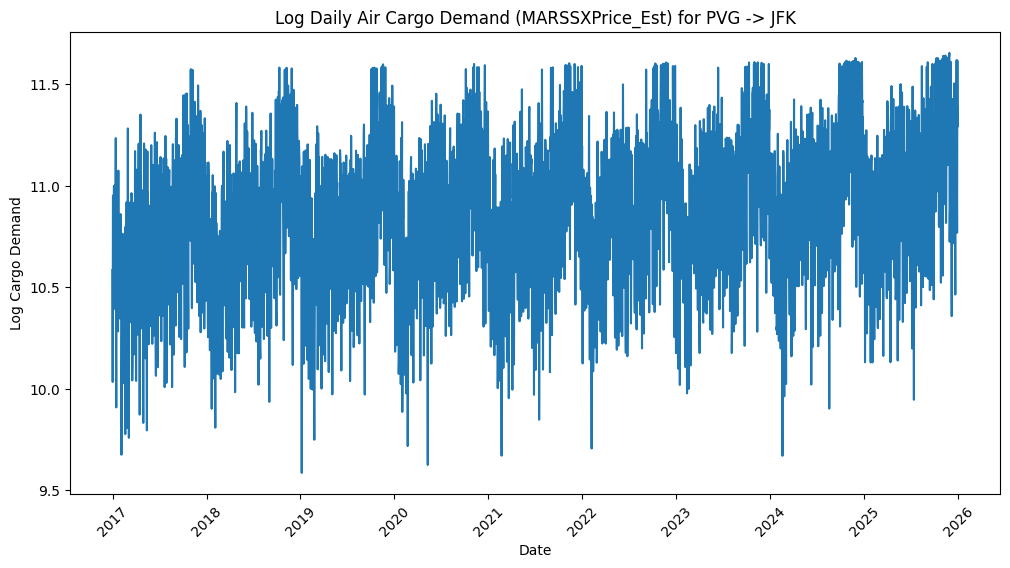

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Demand'])
plt.title('Daily Air Cargo Demand (MARSSXPrice_Est) for PVG -> JFK')
plt.xlabel('Date')
plt.ylabel('Cargo Demand (kg)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Demand'].apply(np.log))
plt.title('Log Daily Air Cargo Demand (MARSSXPrice_Est) for PVG -> JFK')
plt.xlabel('Date')
plt.ylabel('Log Cargo Demand')
plt.xticks(rotation=45)
plt.show()


In [8]:
# 1. Log transform to stabilize variance if the model benefits from it
df['LogDemand'] = np.log(df['Demand'] + 1)  # Add 1 to avoid log(0)

# 2. Manual Split (No shuffling!)
train_size = int(len(df) * 0.8)  # Use the first 80% of the data for training
train, test = df['LogDemand'][:train_size], df['LogDemand'][train_size:]

print(f"Training months: {len(train)}")
print(f"Testing months: {len(test)}")

Training months: 2630
Testing months: 658


## ARIMA

Checking stationarity of log-transformed data:
ADF Statistic: -3.7484098483316117
p-value: 0.0034815199463872496

ADF Statistic: -14.83851996610709
p-value: 1.8524147176965688e-27


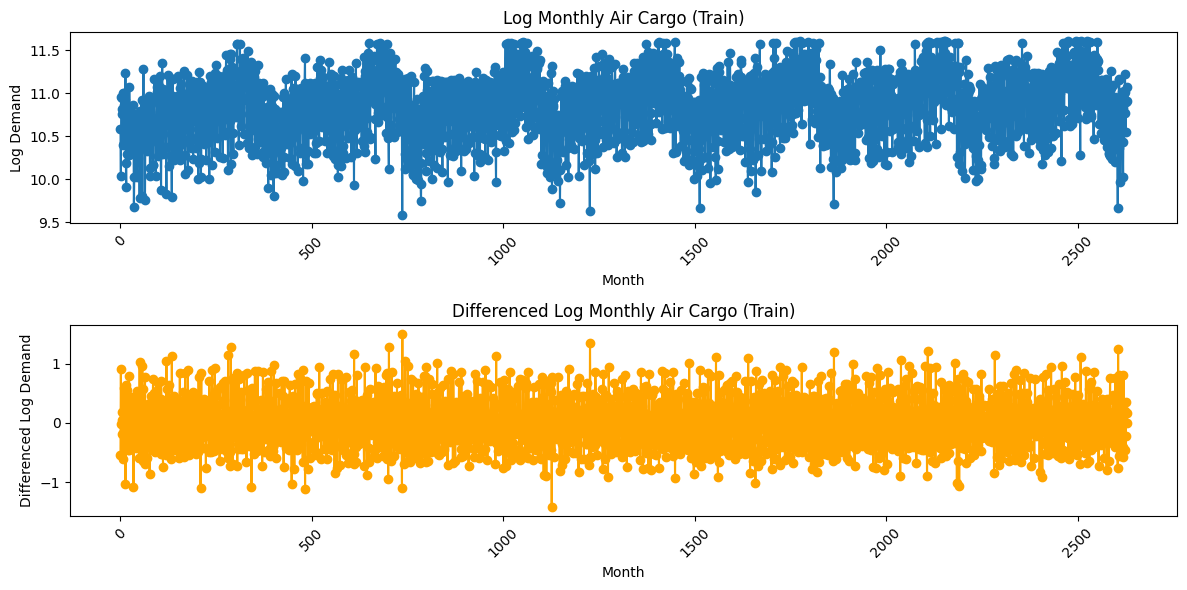

In [9]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')

# Check raw log data
print("Checking stationarity of log-transformed data:")
check_stationarity(train) 
print()

# Differencing to achieve stationarity
train_diff = train.diff().dropna()
check_stationarity(train_diff)

# Plot train_diff vs train to visualize
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(train.index, train, marker='o')
plt.title('Log Monthly Air Cargo (Train)')
plt.xlabel('Month')
plt.ylabel('Log Demand')
plt.xticks(rotation=45)
plt.subplot(2, 1, 2)
plt.plot(train_diff.index, train_diff, marker='o', color='orange')
plt.title('Differenced Log Monthly Air Cargo (Train)')
plt.xlabel('Month')
plt.ylabel('Differenced Log Demand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

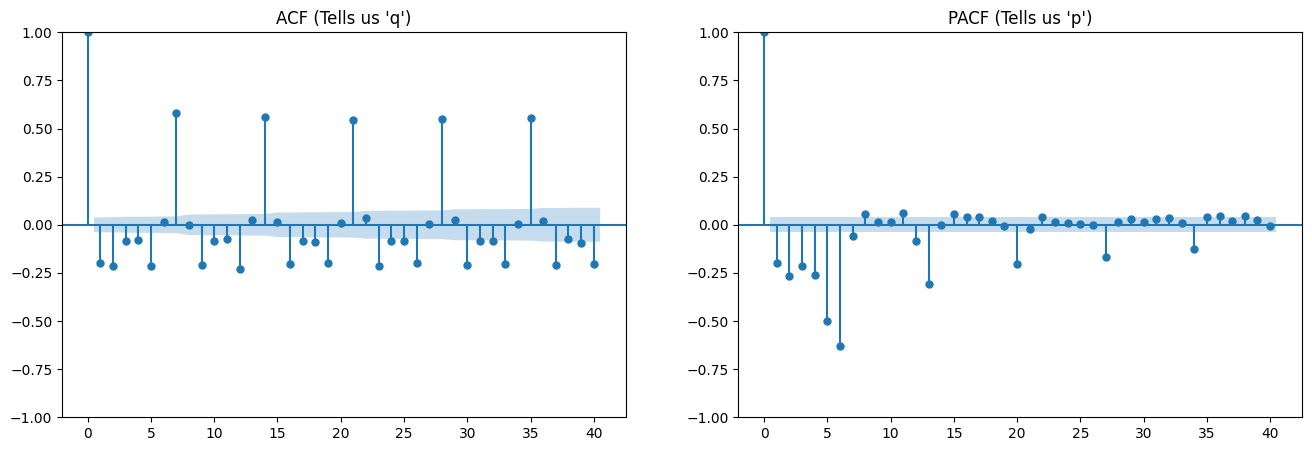

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Use the diffed data (d=1) to find p and q
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(train_diff, lags=40, ax=ax1)
ax1.set_title("ACF (Tells us 'q')")

plot_pacf(train_diff, lags=40, ax=ax2)
ax2.set_title("PACF (Tells us 'p')")

plt.show()

In [11]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Ignore convergence warnings that often pop up during rolling fits
warnings.simplefilter('ignore', ConvergenceWarning) 

# Convert pandas series/arrays to lists for easy appending during the loop
history = list(train)
test_values = list(test)
forecast_log = []

print("Starting rolling ARIMA forecast...")

# 1. Loop through each time step in the test set
for t in tqdm(range(len(test_values))):
    # Fit the model on the current history
    model = ARIMA(history, order=(1, 1, 1))
    model_fit = model.fit()
    
    # Predict exactly 1 step into the future
    yhat = model_fit.forecast(steps=1)[0]
    forecast_log.append(yhat)
    
    # Reveal the true ground-truth for this step and add it to the history
    # This ensures that when predicting t+2, the model knows the true value of t+1
    obs = test_values[t]
    history.append(obs)

print("Rolling forecast complete.")

# 2. Convert back to the original scale (Exp because we used Log)
forecast_arima = np.exp(forecast_log) - 1
actual_test = np.exp(test_values) - 1

# 3. Calculate error
rmse = np.sqrt(mean_squared_error(actual_test, forecast_arima))
print(f"ARIMA RMSE: {rmse:.2f}")

Starting rolling ARIMA forecast...


  0%|          | 0/658 [00:00<?, ?it/s]c:\Users\Ming\anaconda3\envs\ds\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
100%|██████████| 658/658 [03:30<00:00,  3.13it/s]

Rolling forecast complete.
ARIMA RMSE: 20044.53


## SARIMA

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Ignore convergence warnings that pop up during rolling fits
warnings.simplefilter('ignore', ConvergenceWarning) 

# Convert pandas series/arrays to lists for easy appending
history = list(train)
test_values = list(test)
forecast_sarima_log = []

print("Starting rolling SARIMA forecast. This may take a moment...")

# 1. Loop through each time step in the test set
for t in tqdm(range(len(test_values))):
    # Fit the SARIMA model on the current history
    # disp=False prevents it from printing convergence tables on every loop
    model_sarima = SARIMAX(
        history, 
        order=(1, 1, 1), 
        seasonal_order=(0, 1, 1, 7)
    )
    sarima_fit = model_sarima.fit(disp=False)
    
    # Predict exactly 1 step into the future
    yhat = sarima_fit.forecast(steps=1)[0]
    forecast_sarima_log.append(yhat)
    
    # Reveal the true ground-truth for this step and add it to the history
    obs = test_values[t]
    history.append(obs)

print("Rolling forecast complete.")

# 2. Convert back to the original scale (Exp because we used Log)
forecast_sarima = np.exp(forecast_sarima_log) - 1
actual_test = np.exp(test_values) - 1

# 3. Calculate error
rmse_sarima = np.sqrt(mean_squared_error(actual_test, forecast_sarima))
print(f"Rolling SARIMA RMSE: {rmse_sarima:.2f}")

Starting rolling SARIMA forecast. This may take a moment...


100%|██████████| 658/658 [33:29<00:00,  3.05s/it]

Rolling forecast complete.
Rolling SARIMA RMSE: 12948.13


## SD-SVR

In [25]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# -------------------------------
# 1. DATE EXTRACTION & PREPROCESSING
# -------------------------------
df_model = df.copy()

# Assuming your date column is named 'Date'. If it's the index, use df_model.index instead.
df_model['Date'] = pd.to_datetime(df_model['Date'])
df_model['weekday'] = df_model['Date'].dt.weekday
df_model['month'] = df_model['Date'].dt.month

# Log transform target
df_model['Log_Demand'] = np.log(df_model['Demand'] + 1)

# One-hot encode the extracted calendar features
df_model = pd.get_dummies(df_model, columns=['weekday', 'month'], drop_first=True)

# -------------------------------
# 2. DECOMPOSITION (Training Data Only)
# -------------------------------
# Decomposition on training portion only to avoid data leakage
decomp = seasonal_decompose(df_model['Log_Demand'].iloc[:train_size], model='additive', period=7, extrapolate_trend='freq')

components = {
    'trend': decomp.trend.dropna(),
    'seasonal': decomp.seasonal.dropna(),
    'resid': decomp.resid.dropna()
}

# Ensure all components align on the same index
valid_idx = components['trend'].index
for k in components:
    components[k] = components[k].loc[valid_idx]

train_size_adj = len(valid_idx)
test_steps = len(df_model) - train_size_adj 

# Get the names of the one-hot encoded calendar columns
calendar_cols = [c for c in df_model.columns if 'weekday_' in c or 'month_' in c]

# -------------------------------
# 3. HYBRID FORECASTING FUNCTION
# -------------------------------
def forecast_component_with_exog(component_series, full_df, start_idx, steps_to_forecast, lag, param_grid):
    """
    Predicts a decomposed component using its own lags AND the actual calendar features.
    """
    history = list(component_series.values)
    preds = []
    
    # 1. Build Training Data: [Lag_1, Lag_2, ..., Calendar_1, Calendar_2, ...]
    X_train_init, y_train_init = [], []
    for i in range(lag, len(history)):
        # Get lags of the component
        lags = history[i-lag:i]
        # Get calendar features for this specific step
        cal_features = full_df.iloc[i][calendar_cols].values.tolist()
        
        X_train_init.append(lags + cal_features)
        y_train_init.append(history[i])
        
    X_train_init = np.array(X_train_init)
    y_train_init = np.array(y_train_init)
    
    # 2. Fit Scalers ONCE
    scaler_X = StandardScaler().fit(X_train_init)
    scaler_y = StandardScaler().fit(y_train_init.reshape(-1, 1))
    
    X_scaled = scaler_X.transform(X_train_init)
    y_scaled = scaler_y.transform(y_train_init.reshape(-1, 1)).ravel()
    
    # 3. Train SVR with Time Series Cross-Validation
    tscv = TimeSeriesSplit(n_splits=3)
    base_model = SVR(kernel='rbf')
    
    grid_search = GridSearchCV(
        estimator=base_model, 
        param_grid=param_grid, 
        cv=tscv, 
        scoring='neg_mean_squared_error', 
        n_jobs=-1
    )
    
    grid_search.fit(X_scaled, y_scaled)
    model = grid_search.best_estimator_
    print(f"  -> Best params: {grid_search.best_params_}")
    
    # 4. Recursive Forecasting into the Test Set
    current_test_idx = start_idx
    for _ in range(steps_to_forecast):
        # Lags from our rolling history
        last_lags = history[-lag:]
        # Known future calendar features for this step
        future_cal_features = full_df.iloc[current_test_idx][calendar_cols].values.tolist()
        
        # Combine them
        step_features = np.array(last_lags + future_cal_features).reshape(1, -1)
        
        # Scale & Predict
        last_scaled = scaler_X.transform(step_features)
        pred_scaled = model.predict(last_scaled)[0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0][0]
        
        preds.append(pred)
        history.append(pred)
        current_test_idx += 1
        
    return np.array(preds)

# -------------------------------
# 4. EXECUTION
# -------------------------------
# Expanded lags for richer historical context
lags = {
    'trend': 30,
    'seasonal': 14,
    'resid': 7
}

# Parameter grid for SVR tuning
svr_param_grid = {
    'C': [0.1, 1, 10, 50],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'epsilon': [0.001, 0.01, 0.1]
}

pred_components = {}

for name, series in components.items():
    print(f"Training and Forecasting {name} with calendar features...")
    pred_components[name] = forecast_component_with_exog(
        component_series=series,
        full_df=df_model,
        start_idx=train_size_adj,
        steps_to_forecast=test_steps,
        lag=lags[name],
        param_grid=svr_param_grid
    )

# -------------------------------
# 5. RECONSTRUCT & EVALUATE
# -------------------------------
# Sum components in log space (following the paper's multiplicative logic in log-space)
log_forecast = pred_components['trend'] + pred_components['seasonal'] + pred_components['resid']

# Inverse log: exp(x) - 1
forecast_sd_svr = np.exp(log_forecast) - 1

# Align with actual test data
actual_test = df_model['Demand'].iloc[train_size_adj:]
forecast_svr = pd.Series(forecast_sd_svr, index=actual_test.index)

rmse = np.sqrt(mean_squared_error(actual_test, forecast_svr))
print(f"\nOptimization Complete.")
print(f"Hybrid SD-SVR (with Calendar Features) RMSE: {rmse:.2f}")

Training and Forecasting trend with calendar features...
  -> Best params: {'C': 10, 'epsilon': 0.1, 'gamma': 0.01}
Training and Forecasting seasonal with calendar features...
  -> Best params: {'C': 10, 'epsilon': 0.001, 'gamma': 'auto'}
Training and Forecasting resid with calendar features...
  -> Best params: {'C': 1, 'epsilon': 0.1, 'gamma': 0.01}

Optimization Complete.
Hybrid SD-SVR (with Calendar Features) RMSE: 13405.55


## TSformer

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# ── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

In [37]:
# ── Hyperparameters ─────────────────
ENCODER_LEN   = 60   # 60-days look-back window fed to the encoder
DECODER_LEN   = 20    # decoder overlap window (must be < ENCODER_LEN)
FORECAST_LEN  = 1    # one-step-ahead forecast
D_MODEL       = 64   # embedding dimension
N_HEADS       = 4    # attention heads
N_ENC_LAYERS  = 3
N_DEC_LAYERS  = 3
FFN_DIM       = 256
DROPOUT       = 0.2
EPOCHS        = 300
LR            = 1e-3
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cuda


In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# ── 1. Log Transform then Scale to [0, 1] ────────────────────────────────────
# Apply the log1p transform to the entire demand array first
log_demand = np.log1p(df["Demand"].values)

scaler = MinMaxScaler()
# Fit only on the training portion of the log-transformed data
scaler.fit(log_demand[:train_size].reshape(-1, 1)) 

# Transform the entire log-demand array
passengers_scaled = scaler.transform(
    log_demand.reshape(-1, 1)
).flatten()

# ── 2. Add calendar features (Weekday and Month) ─────────────────────────────
# The paper encodes January-December as 0-11 and Monday-Sunday as 0-6.
months = df["Date"].dt.month.values - 1    # Convert 1-12 to 0-11
weekdays = df["Date"].dt.weekday.values    # Already 0-6 in pandas

# Min-Max normalize them to [0, 1] to match the paper's preprocessing step
months_scaled = months / 11.0
weekdays_scaled = weekdays / 6.0

# ── 3. Build feature matrix  [passengers_scaled, months_scaled, weekdays_scaled] ─
features = np.stack([passengers_scaled, months_scaled, weekdays_scaled], axis=1)
N_FEATURES = features.shape[1]

# ── 4. Rolling-window dataset builder ────────────────────────────────────────
def build_sequences(data, enc_len, dec_len, forecast_len):
    """
    Returns
    -------
    enc_inputs  : (N, enc_len,   n_features)
    dec_inputs  : (N, dec_len+1, n_features)   last token = calendar only
    targets     : (N, forecast_len)
    """
    X_enc, X_dec, Y = [], [], []
    total = enc_len + forecast_len
    for i in range(len(data) - total + 1):
        enc_seq = data[i : i + enc_len]                         # history
        # decoder overlap comes from the tail of the encoder window
        dec_known = data[i + enc_len - dec_len : i + enc_len]
        
        # forecast token: zero out passenger count, keep calendar
        token = dec_known[-1].copy()
        # Ensure we only mask the target demand (index 0). 
        # The calendar features (indices 1 and 2) remain visible to the decoder.
        token[0] = 0.0                                          
        
        dec_seq = np.vstack([dec_known, token])                 # (dec_len+1, F)
        target  = data[i + enc_len : i + enc_len + forecast_len, 0]
        
        X_enc.append(enc_seq)
        X_dec.append(dec_seq)
        Y.append(target)
        
    return (np.array(X_enc, dtype=np.float32),
            np.array(X_dec, dtype=np.float32),
            np.array(Y,     dtype=np.float32))

enc_inputs, dec_inputs, targets = build_sequences(
    features, ENCODER_LEN, DECODER_LEN, FORECAST_LEN
)
print(f"Sequences built → enc:{enc_inputs.shape}  dec:{dec_inputs.shape}  y:{targets.shape}")

# ── 5. Train / test split (keep temporal order!) ─────────────────────────────
# Align with the existing `train_size` split used earlier in the notebook
n_samples = enc_inputs.shape[0]
split = train_size - ENCODER_LEN - FORECAST_LEN + 1

enc_train, enc_test = enc_inputs[:split], enc_inputs[split:]
dec_train, dec_test = dec_inputs[:split], dec_inputs[split:]
y_train,   y_test   = targets[:split],   targets[split:]

print(f"Train samples: {len(enc_train)} | Test samples: {len(enc_test)}")

# ── 6. PyTorch tensors ────────────────────────────────────────────────────────
enc_train_t = torch.tensor(enc_train).to(DEVICE)
dec_train_t = torch.tensor(dec_train).to(DEVICE)
y_train_t   = torch.tensor(y_train).to(DEVICE)
enc_test_t  = torch.tensor(enc_test).to(DEVICE)
dec_test_t  = torch.tensor(dec_test).to(DEVICE)

print(f"Encoder train tensor: {enc_train_t.shape}  Decoder train tensor: {dec_train_t.shape}  Target train tensor: {y_train_t.shape}")
print(f"Encoder test tensor: {enc_test_t.shape}  Decoder test tensor: {dec_test_t.shape}")

Sequences built → enc:(3228, 60, 3)  dec:(3228, 21, 3)  y:(3228, 1)
Train samples: 2570 | Test samples: 658
Encoder train tensor: torch.Size([2570, 60, 3])  Decoder train tensor: torch.Size([2570, 21, 3])  Target train tensor: torch.Size([2570, 1])
Encoder test tensor: torch.Size([658, 60, 3])  Decoder test tensor: torch.Size([658, 21, 3])


In [39]:
# ── 7. Tsformer Architecture ──────────────────────────────────────────────────
class SinusoidalPE(nn.Module):
    """Fixed sinusoidal positional encoding."""
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]


def causal_mask(sz, device):
    """Upper-triangular mask filled with -inf (encoder source / decoder target)."""
    mask = torch.triu(torch.full((sz, sz), float("-inf"), device=device), diagonal=1)
    return mask                                          # (sz, sz)


def memory_mask(dec_len, enc_len, device):
    """
    Decoder memory mask: each decoder step i can only attend to encoder
    positions 0 … (i + enc_len - dec_len).
    """
    mask = torch.full((dec_len, enc_len), float("-inf"), device=device)
    for i in range(dec_len):
        allowed = i + (enc_len - dec_len)
        mask[i, : allowed + 1] = 0.0
    return mask                                          # (dec_len, enc_len)


class Tsformer(nn.Module):
    def __init__(self, n_features, d_model, n_heads,
                 n_enc, n_dec, ffn_dim, dropout,
                 enc_len, dec_len, forecast_len):
        super().__init__()
        # Paper replaces embedding layer with a fully connected layer
        self.enc_input_fc = nn.Linear(n_features, d_model)
        self.dec_input_fc = nn.Linear(n_features, d_model)
        self.pe = SinusoidalPE(d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=ffn_dim, dropout=dropout,
            activation=F.elu, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_enc)

        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=ffn_dim, dropout=dropout,
            activation=F.elu, batch_first=True
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=n_dec)

        # No Softmax at the end → regression output
        self.fc_out = nn.Linear(d_model, 1)

        self.enc_len = enc_len
        self.dec_len = dec_len          # decoder input rows excluding forecast token
        self.forecast_len = forecast_len

    def forward(self, src, tgt):
        """
        src : (B, enc_len, n_features)
        tgt : (B, dec_len+1, n_features)   last position = forecast token
        """
        # Input projection + positional encoding
        src = self.pe(self.enc_input_fc(src))
        tgt = self.pe(self.dec_input_fc(tgt))

        B, S, _ = src.shape
        _, T, _ = tgt.shape

        # Masks
        src_mask  = causal_mask(S, src.device)                 # encoder source mask
        tgt_mask  = causal_mask(T, tgt.device)                 # decoder target mask
        mem_mask  = memory_mask(T, S, src.device)              # decoder memory mask

        memory = self.encoder(src, mask=src_mask)
        out    = self.decoder(tgt, memory,
                              tgt_mask=tgt_mask,
                              memory_mask=mem_mask)

        # Take the output at the forecast token position (last step)
        pred = self.fc_out(out[:, -self.forecast_len:, :])     # (B, 1, 1)
        return pred.squeeze(-1)                                 # (B, forecast_len)

Tsformer parameters: 350,785


c:\Users\Ming\anaconda3\envs\ds\lib\site-packages\torch\nn\modules\transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.activation_relu_or_gelu was not True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch   50/300  |  Train MSE: 0.033938
Epoch  100/300  |  Train MSE: 0.018900
Epoch  150/300  |  Train MSE: 0.011965
Epoch  200/300  |  Train MSE: 0.011167
Epoch  250/300  |  Train MSE: 0.011073
Epoch  300/300  |  Train MSE: 0.010850


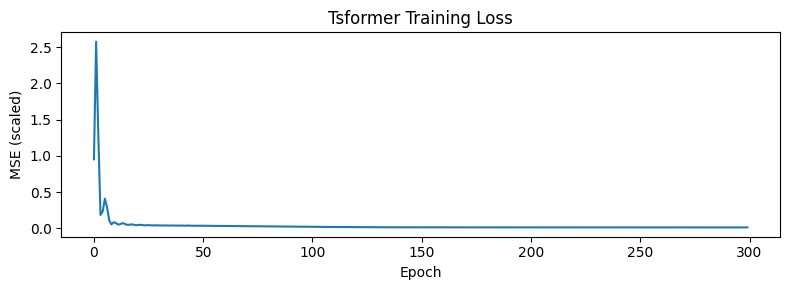

In [40]:
# ── 8. Execution ──────────────────────────────────────────────────────────────
model = Tsformer(
    n_features   = N_FEATURES,
    d_model      = D_MODEL,
    n_heads      = N_HEADS,
    n_enc        = N_ENC_LAYERS,
    n_dec        = N_DEC_LAYERS,
    ffn_dim      = FFN_DIM,
    dropout      = DROPOUT,
    enc_len      = ENCODER_LEN,
    dec_len      = DECODER_LEN,
    forecast_len = FORECAST_LEN,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Tsformer parameters: {n_params:,}")

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.MSELoss()

train_losses = []
model.train()

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()
    pred  = model(enc_train_t, dec_train_t)          # (N_train, 1)
    loss  = criterion(pred, y_train_t)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()
    train_losses.append(loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d}/{EPOCHS}  |  Train MSE: {loss.item():.6f}")

plt.figure(figsize=(8, 3))
plt.plot(train_losses)
plt.title("Tsformer Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE (scaled)")
plt.tight_layout()
plt.show()

In [41]:
model.eval()
with torch.no_grad():
    pred_scaled = model(enc_test_t, dec_test_t).cpu().numpy()   # (N_test, 1)

# Inverse-transform back to passenger counts (un-scale, then un-log)
pred_inv = np.expm1(scaler.inverse_transform(pred_scaled))                # (N_test, 1)
true_inv = np.expm1(scaler.inverse_transform(y_test))                     # (N_test, 1)

rmse_tsformer = np.sqrt(mean_squared_error(true_inv, pred_inv))
print(f"Tsformer RMSE: {rmse_tsformer:.2f}")

Tsformer RMSE: 13012.59


## Comparison

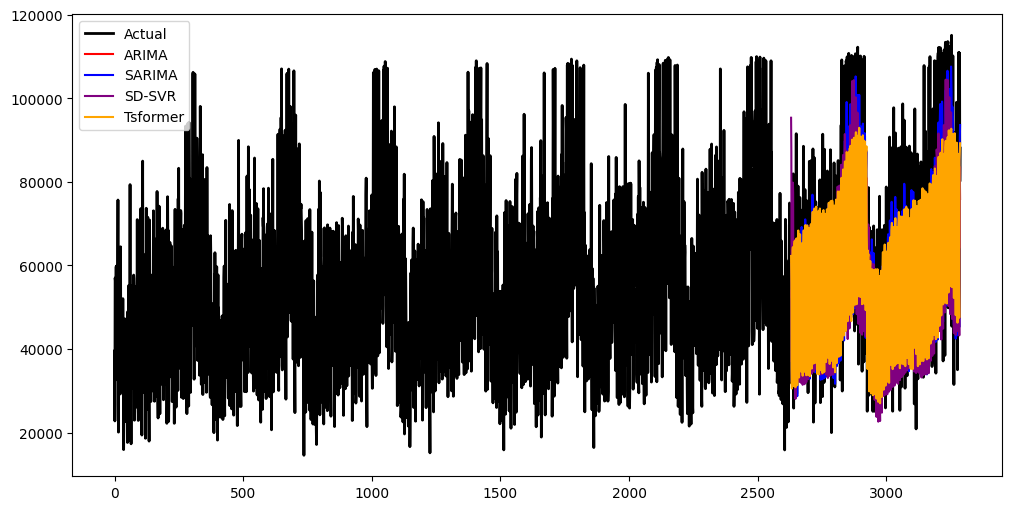

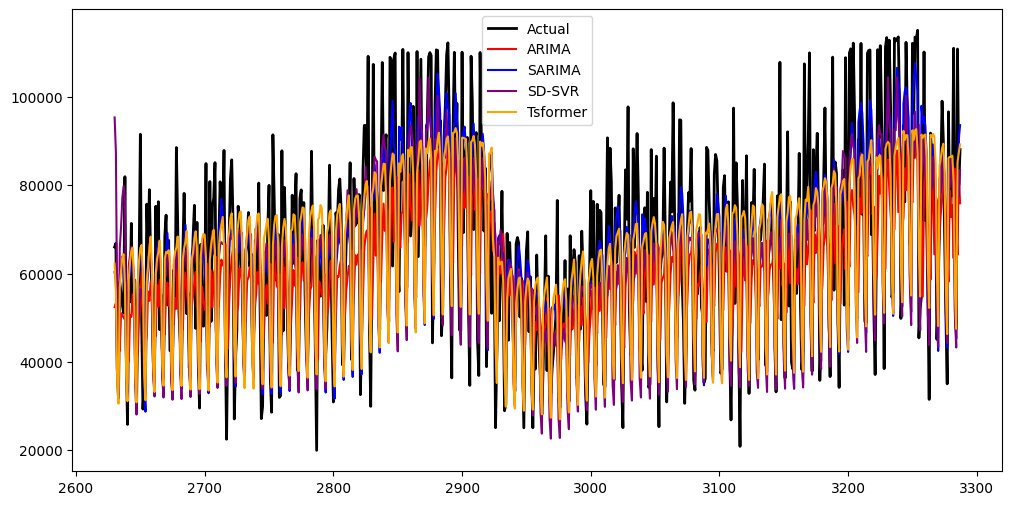

In [42]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Demand'], label='Actual', color='black', linewidth=2)
plt.plot(df.index[-len(test):], forecast_arima, label='ARIMA', color='red')
plt.plot(df.index[-len(test):], forecast_sarima, label='SARIMA', color='blue')
plt.plot(df.index[-len(test):], forecast_svr, label='SD-SVR', color='purple')
plt.plot(df.index[-len(test):], pred_inv.flatten(), label='Tsformer', color='orange')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(test):], actual_test, label='Actual', color='black', linewidth=2)
plt.plot(df.index[-len(test):], forecast_arima, label='ARIMA', color='red')
plt.plot(df.index[-len(test):], forecast_sarima, label='SARIMA', color='blue')
plt.plot(df.index[-len(test):], forecast_svr, label='SD-SVR', color='purple')
plt.plot(df.index[-len(test):], pred_inv.flatten(), label='Tsformer', color='orange')
plt.legend()
plt.show()

In [43]:
results_df = pd.DataFrame({
    'Date': np.asarray(df.index[-len(test):]).ravel(),
    'Unconstrained_Groundtruth': np.asarray(actual_test).ravel(),
    'ARIMA': np.asarray(forecast_arima).ravel(),
    'SARIMA': np.asarray(forecast_sarima).ravel(),
    'SD-SVR': np.asarray(forecast_svr).ravel(),
    'Tsformer': np.asarray(pred_inv).ravel()
})

results_df.to_csv("PVG_JFK_MARSSXPrice_Est.csv", index=False)

In [44]:
# Compute RMSE
rmse_arima = np.sqrt(mean_squared_error(actual_test, forecast_arima))
rmse_sarima = np.sqrt(mean_squared_error(actual_test, forecast_sarima))
rmse_svr = np.sqrt(mean_squared_error(actual_test, forecast_svr))

# Put into DataFrame
rmse_df = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA', 'SD-SVR', 'Tsformer'],
    'RMSE': [rmse_arima, rmse_sarima, rmse_svr, rmse_tsformer]
})

rmse_df

,Model,RMSE
0,ARIMA,20044.532375
1,SARIMA,12948.132584
2,SD-SVR,13405.547825
3,Tsformer,13012.590820


In [45]:
print("\n" + rmse_df.to_markdown(index=False) + "\n")


| Model    |    RMSE |
|:---------|--------:|
| ARIMA    | 20044.5 |
| SARIMA   | 12948.1 |
| SD-SVR   | 13405.5 |
| Tsformer | 13012.6 |

